In [1]:
# Cell 1: Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plots
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Visualization libraries imported successfully!")

✅ Visualization libraries imported successfully!


In [2]:
# Cell 2: Load the generated crowd dataset
file_path = "E:/CrowdShield/Data/crowd_data.csv" 
df = pd.read_csv(file_path)

print("🔍 First 5 rows of the dataset:")
display(df.head())

🔍 First 5 rows of the dataset:


,zone_id,density,speed,risk_label
0,4,712,1.659673,1
1,5,449,0.159274,2
2,3,120,2.044622,0
3,5,229,1.387788,0
4,5,173,0.767721,0


In [3]:
# Cell 3: Check for missing values and basic statistics
print("📊 Dataset Information:")
df.info()

print("\n🚨 Missing Values Check:")
print(df.isnull().sum())

print("\n📈 Statistical Summary:")
display(df.describe())

📊 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   zone_id     5000 non-null   int64  
 1   density     5000 non-null   int64  
 2   speed       5000 non-null   float64
 3   risk_label  5000 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 156.4 KB

🚨 Missing Values Check:
zone_id       0
density       0
speed         0
risk_label    0
dtype: int64

📈 Statistical Summary:


,zone_id,density,speed,risk_label
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.010800,423.685000,1.290528,0.823800
std,1.424601,216.125812,0.687393,0.769462
min,1.000000,50.000000,0.100127,0.000000
25%,2.000000,236.000000,0.705323,0.000000
50%,3.000000,422.500000,1.280479,1.000000
75%,4.000000,609.000000,1.882608,1.000000
max,5.000000,799.000000,2.499216,2.000000


C:\Users\HP\AppData\Local\Temp\ipykernel_7192\934394434.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='risk_label', palette=['#00e5ff', '#f59e0b', '#ff003c'])


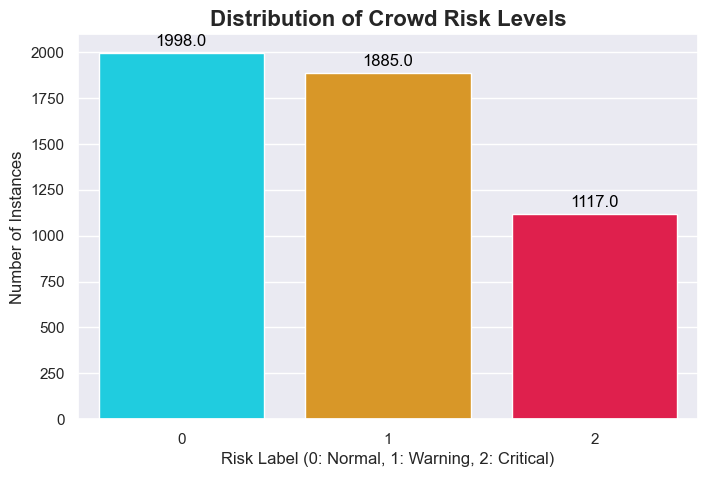

In [4]:
# Cell 4: Distribution of Risk Labels (Target Variable)
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='risk_label', palette=['#00e5ff', '#f59e0b', '#ff003c'])

# Adding labels and titles
plt.title('Distribution of Crowd Risk Levels', fontsize=16, fontweight='bold')
plt.xlabel('Risk Label (0: Normal, 1: Warning, 2: Critical)', fontsize=12)
plt.ylabel('Number of Instances', fontsize=12)

# Adding count numbers on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

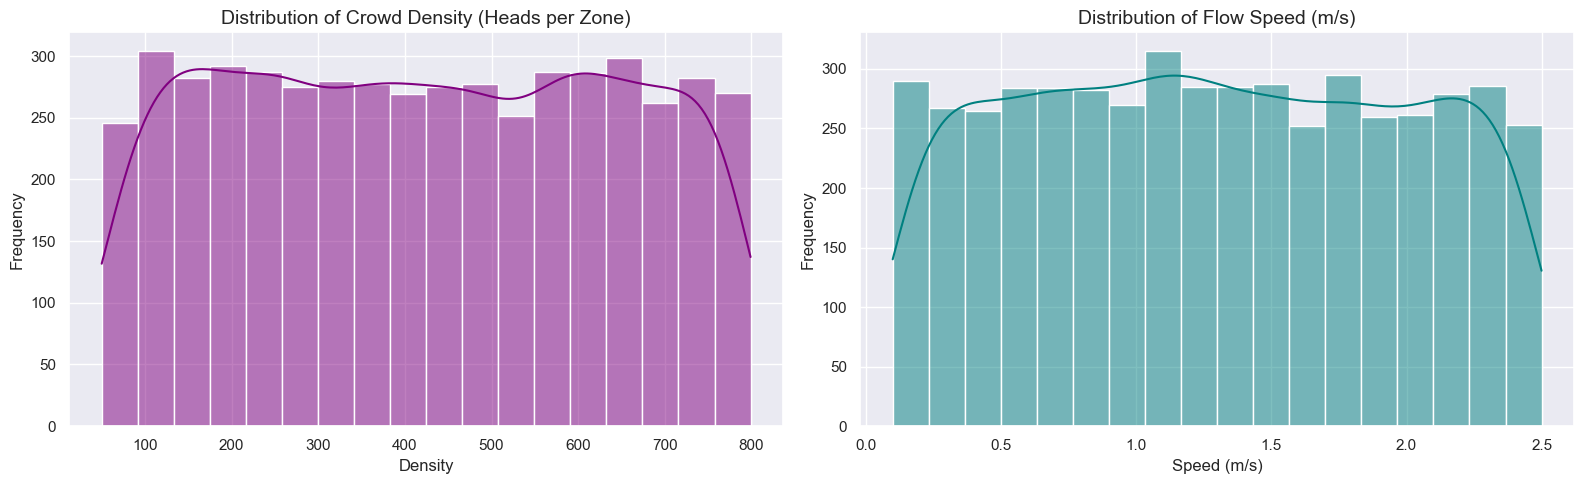

In [5]:
# Cell 5: Distribution of Crowd Density and Flow Speed
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Density Distribution
sns.histplot(df['density'], kde=True, ax=axes[0], color='purple')
axes[0].set_title('Distribution of Crowd Density (Heads per Zone)', fontsize=14)
axes[0].set_xlabel('Density')
axes[0].set_ylabel('Frequency')

# Speed Distribution
sns.histplot(df['speed'], kde=True, ax=axes[1], color='teal')
axes[1].set_title('Distribution of Flow Speed (m/s)', fontsize=14)
axes[1].set_xlabel('Speed (m/s)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

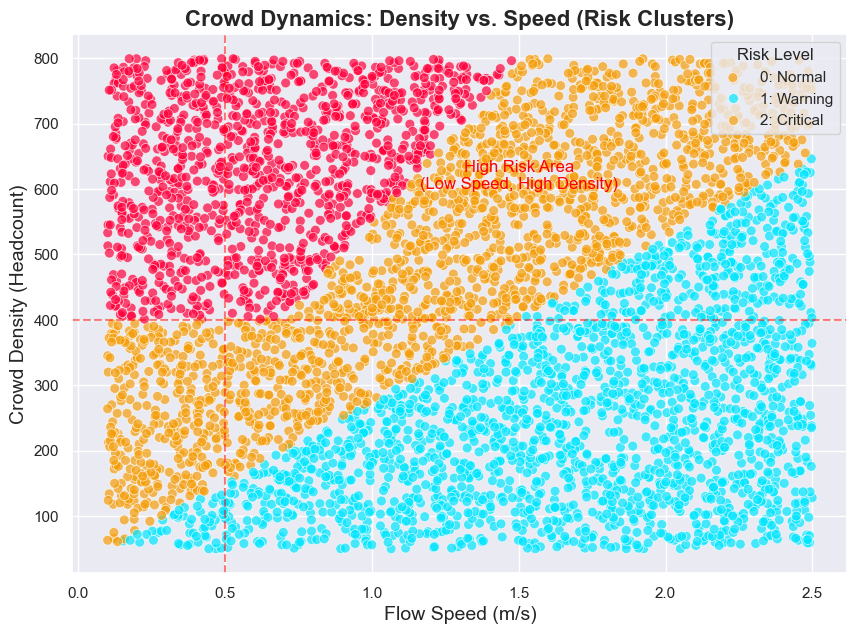

In [6]:
# Cell 6: Scatter Plot of Density vs. Speed classified by Risk Label
plt.figure(figsize=(10, 7))

# Create a scatter plot mapping colors to risk labels
sns.scatterplot(
    data=df, 
    x='speed', 
    y='density', 
    hue='risk_label', 
    palette=['#00e5ff', '#f59e0b', '#ff003c'], 
    alpha=0.7,
    s=50
)

plt.title('Crowd Dynamics: Density vs. Speed (Risk Clusters)', fontsize=16, fontweight='bold')
plt.xlabel('Flow Speed (m/s)', fontsize=14)
plt.ylabel('Crowd Density (Headcount)', fontsize=14)
plt.legend(title='Risk Level', labels=['0: Normal', '1: Warning', '2: Critical'])

# Adding a visual notation for the 'Danger Zone'
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
plt.axhline(y=400, color='red', linestyle='--', alpha=0.5)
plt.text(1.5, 600, 'High Risk Area\n(Low Speed, High Density)', color='red', fontsize=12, ha='center')

plt.show()

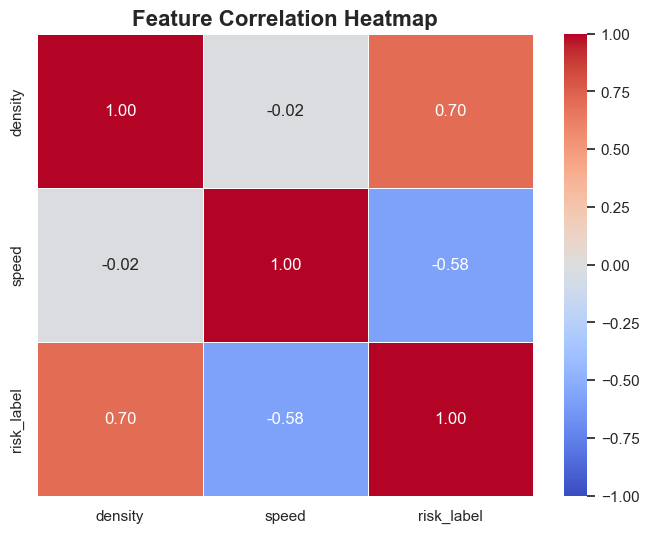

In [7]:
# Cell 7: Correlation Matrix Heatmap
plt.figure(figsize=(8, 6))

# Calculate correlation matrix
corr_matrix = df[['density', 'speed', 'risk_label']].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)

plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold')
plt.show()

### 📝 EDA Summary & Justification for Modeling

1. **Clean Data**: The dataset contains 5,000 observations with zero missing values, meaning no imputation was required.
2. **Feature Relationships**: As seen in the scatter plot, the relationship between Crowd Density and Flow Speed is non-linear when predicting the Risk Label. High density alone does not cause a stampede if the flow speed is also high. The danger only triggers when density is high **AND** speed is low (bottleneck).
3. **Why Random Forest/Gradient Boosting?**: Because the decision boundary between Normal, Warning, and Critical is complex and non-linear, standard linear models (like simple Logistic Regression) will underperform. Tree-based ensemble models (Random Forest) are perfectly suited to capture these non-linear density-speed clusters.